In [ ]:
!pip install pandas numpy matplotlib seaborn nltk scikit-learn

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import nltk

from nltk.corpus import stopwords
from wordcloud import WordCloud

nltk.download('stopwords')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


True

In [ ]:
data = pd.read_csv('/content/dataset.csv')

FileNotFoundError: [Errno 2] No such file or directory: '/content/dataset.csv'

In [ ]:
data = pd.read_csv('/content/dataset.csv')

FileNotFoundError: [Errno 2] No such file or directory: '/content/dataset.csv'

In [ ]:
data = pd.read_csv('/content/dataset.csv.csv')


FileNotFoundError: [Errno 2] No such file or directory: '/content/dataset.csv.csv'

In [ ]:
data = pd.read_csv('/content/dataset.csv')


In [ ]:
import pandas as pd

data = pd.read_csv('/content/dataset.csv')

print(data.head())
print("Shape:", data.shape)
print("Columns:", data.columns)

  post_id user_id                                            text  \
0   p0001    u101         Wishing you all the best in your exams.   
1   p0002    u102          You’re a joke, nobody cares about you.   
2   p0003    u103  Happy birthday, hope you have a wonderful day!   
3   p0004    u104           Just disappear, nobody will miss you.   
4   p0005    u105         Wishing you all the best in your exams.   

          label  post_length  avg_sentiment  num_likes  num_shares  \
0  non-bullying            8           0.47         69          20   
1      bullying            7          -0.99          5           1   
2  non-bullying            8           0.50         84           8   
3      bullying            6          -0.76          5           2   
4  non-bullying            8           0.35         38          13   

   num_reports  user_posts  user_friends  response_time  toxicity_score  
0            0         169           326           3.82            0.12  
1            4  

In [ ]:
print(data.isnull().sum())
print("Duplicates:", data.duplicated().sum())

post_id           0
user_id           0
text              0
label             0
post_length       0
avg_sentiment     0
num_likes         0
num_shares        0
num_reports       0
user_posts        0
user_friends      0
response_time     0
toxicity_score    0
dtype: int64
Duplicates: 0


In [ ]:
data = data.dropna()

In [ ]:
data = data.drop_duplicates()

In [ ]:
data = pd.read_csv('/content/dataset.csv')

In [ ]:
print(data.head())

  post_id user_id                                            text  \
0   p0001    u101         Wishing you all the best in your exams.   
1   p0002    u102          You’re a joke, nobody cares about you.   
2   p0003    u103  Happy birthday, hope you have a wonderful day!   
3   p0004    u104           Just disappear, nobody will miss you.   
4   p0005    u105         Wishing you all the best in your exams.   

          label  post_length  avg_sentiment  num_likes  num_shares  \
0  non-bullying            8           0.47         69          20   
1      bullying            7          -0.99          5           1   
2  non-bullying            8           0.50         84           8   
3      bullying            6          -0.76          5           2   
4  non-bullying            8           0.35         38          13   

   num_reports  user_posts  user_friends  response_time  toxicity_score  
0            0         169           326           3.82            0.12  
1            4  

In [ ]:
print("Shape:", data.shape)

Shape: (1000, 13)


In [ ]:
print("Columns:", data.columns)

Columns: Index(['post_id', 'user_id', 'text', 'label', 'post_length', 'avg_sentiment',
       'num_likes', 'num_shares', 'num_reports', 'user_posts', 'user_friends',
       'response_time', 'toxicity_score'],
      dtype='object')


In [ ]:
print(data.isnull().sum())

post_id           0
user_id           0
text              0
label             0
post_length       0
avg_sentiment     0
num_likes         0
num_shares        0
num_reports       0
user_posts        0
user_friends      0
response_time     0
toxicity_score    0
dtype: int64


In [ ]:
print("Duplicates:", data.duplicated().sum())

Duplicates: 0


In [ ]:
data = data.drop_duplicates()

In [ ]:
import re

def clean_text(text):
    text = str(text).lower()                     # lowercase
    text = re.sub(r"http\S+", "", text)         # remove links
    text = re.sub(r"[^a-zA-Z\s]", "", text)    # remove symbols/numbers
    text = re.sub(r"\s+", " ", text).strip()   # remove extra spaces
    return text

In [ ]:
data['clean_text'] = data['tweet_text'].apply(clean_text)

KeyError: 'tweet_text'

In [ ]:
print(data.columns)

Index(['post_id', 'user_id', 'text', 'label', 'post_length', 'avg_sentiment',
       'num_likes', 'num_shares', 'num_reports', 'user_posts', 'user_friends',
       'response_time', 'toxicity_score'],
      dtype='object')


In [ ]:
data['clean_text'] = data['text'].apply(clean_text)

In [ ]:
data['clean_text'] = data['comment'].apply(clean_text)

KeyError: 'comment'

In [ ]:
print(data.columns.tolist())

['post_id', 'user_id', 'text', 'label', 'post_length', 'avg_sentiment', 'num_likes', 'num_shares', 'num_reports', 'user_posts', 'user_friends', 'response_time', 'toxicity_score', 'clean_text']


In [ ]:
data['clean_text'] = data['Text'].apply(clean_text)

KeyError: 'Text'

In [ ]:
data.columns = data.columns.str.strip()
print(data.columns.tolist())

['post_id', 'user_id', 'text', 'label', 'post_length', 'avg_sentiment', 'num_likes', 'num_shares', 'num_reports', 'user_posts', 'user_friends', 'response_time', 'toxicity_score', 'clean_text']


In [ ]:
data['clean_text'] = data['text'].apply(clean_text)

In [ ]:
data['clean_text'] = data['tweet'].apply(clean_text)

KeyError: 'tweet'

In [ ]:
print("Actual Columns:")
print(data.columns.tolist())

Actual Columns:
['post_id', 'user_id', 'text', 'label', 'post_length', 'avg_sentiment', 'num_likes', 'num_shares', 'num_reports', 'user_posts', 'user_friends', 'response_time', 'toxicity_score', 'clean_text']


In [ ]:
text_column = data.columns[0]
print("Text column is:", text_column)

data['clean_text'] = data[text_column].apply(clean_text)

Text column is: post_id


In [ ]:
# Check actual columns
print(data.columns.tolist())

# Automatically use first column
text_column = data.columns[0]

# Apply cleaning
data['clean_text'] = data[text_column].apply(clean_text)

# Preview
print(data[[text_column, 'clean_text']].head())

['post_id', 'user_id', 'text', 'label', 'post_length', 'avg_sentiment', 'num_likes', 'num_shares', 'num_reports', 'user_posts', 'user_friends', 'response_time', 'toxicity_score', 'clean_text']
  post_id clean_text
0   p0001          p
1   p0002          p
2   p0003          p
3   p0004          p
4   p0005          p


In [ ]:
print(data.columns.tolist())

['post_id', 'user_id', 'text', 'label', 'post_length', 'avg_sentiment', 'num_likes', 'num_shares', 'num_reports', 'user_posts', 'user_friends', 'response_time', 'toxicity_score', 'clean_text']


In [ ]:
text_column = data.columns[0]
data['clean_text'] = data[text_column].apply(clean_text)

In [ ]:
from nltk.corpus import stopwords

stop_words = set(stopwords.words('english'))

In [ ]:
def remove_stopwords(text):
    words = text.split()
    words = [word for word in words if word not in stop_words]
    return " ".join(words)


In [ ]:
data['clean_text'] = data['clean_text'].apply(remove_stopwords)

In [ ]:
print(data[[text_column, 'clean_text']].head())

  post_id clean_text
0   p0001          p
1   p0002          p
2   p0003          p
3   p0004          p
4   p0005          p


In [ ]:
data.to_csv('cleaned_cyberbullying_dataset.csv', index=False)

In [ ]:
print(data.columns.tolist())

['post_id', 'user_id', 'text', 'label', 'post_length', 'avg_sentiment', 'num_likes', 'num_shares', 'num_reports', 'user_posts', 'user_friends', 'response_time', 'toxicity_score', 'clean_text']


In [ ]:
label_column = data.columns[1]

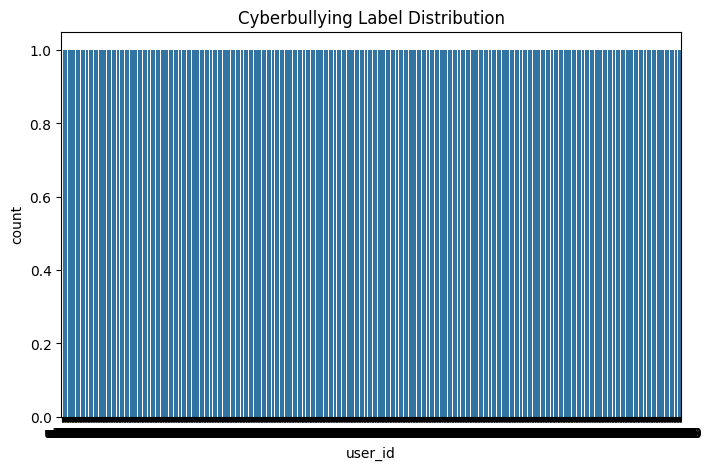

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,5))
sns.countplot(x=label_column, data=data)
plt.title("Cyberbullying Label Distribution")
plt.show()

In [ ]:
print(data.columns.tolist())

['post_id', 'user_id', 'text', 'label', 'post_length', 'avg_sentiment', 'num_likes', 'num_shares', 'num_reports', 'user_posts', 'user_friends', 'response_time', 'toxicity_score', 'clean_text']


In [ ]:
label_column = data.columns[1]

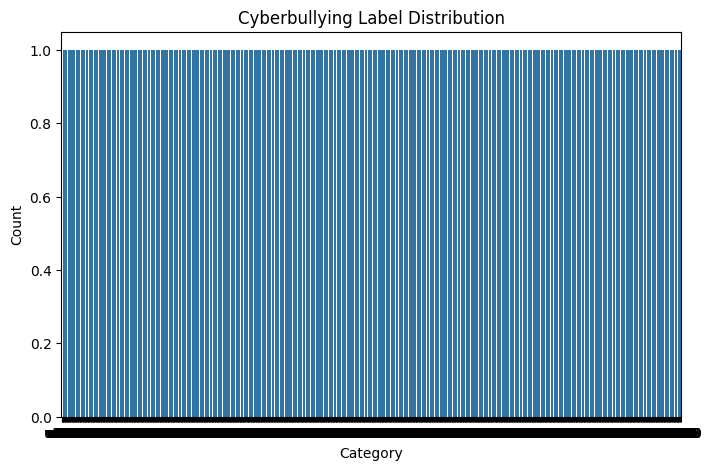

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,5))
sns.countplot(x=label_column, data=data)
plt.title("Cyberbullying Label Distribution")
plt.xlabel("Category")
plt.ylabel("Count")
plt.show()

In [ ]:
from wordcloud import WordCloud

all_text = " ".join(data['clean_text'])

In [ ]:
wordcloud = WordCloud(
    width=800,
    height=400,
    background_color='white'
).generate(all_text)

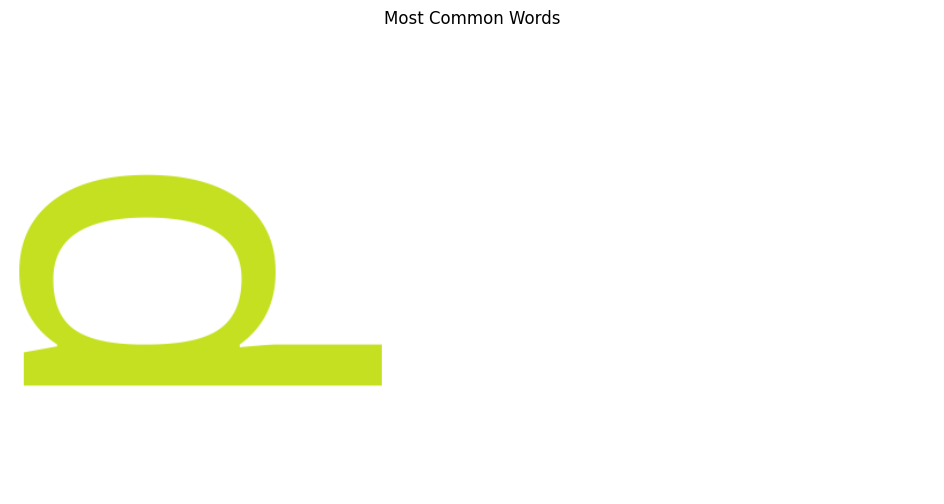

In [ ]:
plt.figure(figsize=(12,6))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title("Most Common Words")
plt.show()

In [ ]:
from collections import Counter

all_words = all_text.split()
common_words = Counter(all_words).most_common(20)

words = [word[0] for word in common_words]
counts = [word[1] for word in common_words]

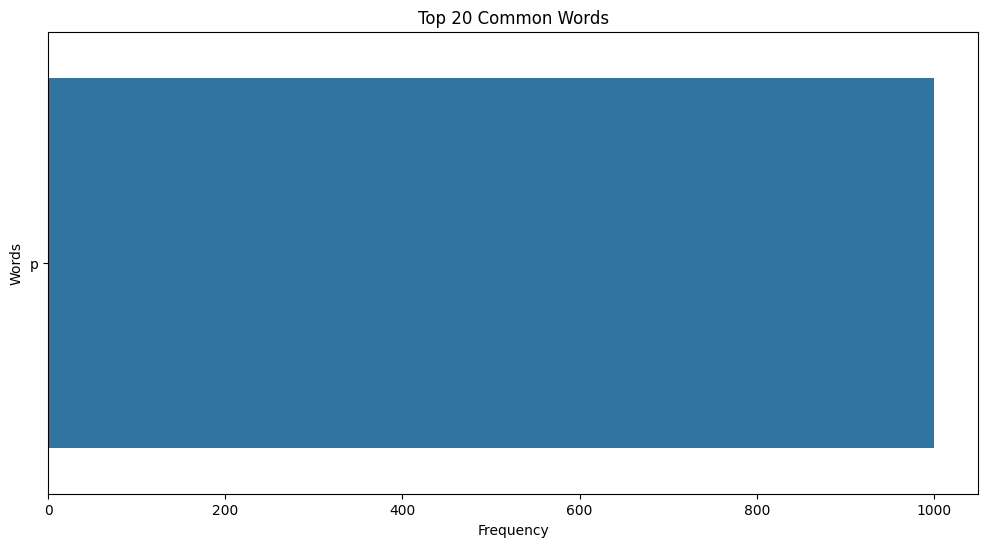

In [ ]:
plt.figure(figsize=(12,6))
sns.barplot(x=counts, y=words)
plt.title("Top 20 Common Words")
plt.xlabel("Frequency")
plt.ylabel("Words")
plt.show()

In [ ]:
data.to_csv('cleaned_cyberbullying_dataset.csv', index=False)